In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [6]:
# CHANG THIS !!!!!
# ckpt_path = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/pde_params_meshgrid/lightning_logs/version_1/checkpoints/epoch=173-total_loss=71.06096649.ckpt"
ckpt_path ="logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/pde_neighborloss/lightning_logs/version_0/checkpoints/epoch=297-total_loss=18.10657692.ckpt"

In [7]:
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

In [8]:
pde_model = model_class.load_from_checkpoint(ckpt_path)

# load data

In [9]:
# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 5
n_grid = 50


In [11]:
# the DS
from torch.utils.data import DataLoader
train_DS = reader.AllTimepoint_MeshGrid(AnnData=adata, 
                                resampling_indensity=0.3, 
                                resampling_rate=0,
                                n_timepoint = n_timepoint,
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                timepoint_key = 'timepoint',
								replicate_key = ''
                                n_grid=n_grid,  
                                nearby_cellstate=3, 
                                collocation_points=300, 
                                log_transform=False,
                                norm_time = False,
                                n_repeat=2)

batch_size = 50
train_DL = DataLoader(train_DS, batch_size=batch_size, num_workers=10, shuffle=False)



KeyError: None

In [36]:
# adata
t7_ad = train_DS.adata.copy()
init_u_b = train_DS.u_b
cellstate = torch.from_numpy(train_DS.cellstate).float().requires_grad_()

# prediction

In [20]:
t_b = train_DS.t_b[:,0]
t_list = t_b / 5
t_list

array([0.2       , 0.46666667, 0.8       , 1.8       , 3.26666667])

In [5]:
## predict u with ode integrat
u_int_all = [u_b[0]]
chunk_size= 500
# t_list = timepoints / 15
it = 0
for it in tqdm(range(n_timepoint-1)):
    t0 = t_list[it]
    t1 = t_list[it+1]
    u_t_ls = []

    for train_batch in train_DL:

        (s_bund,s_neighbor), t_b, (u_b, u_neighbor) = train_batch
        s0 = cellstate.to(device)

        ut0 = u_b[:,it]
        utp1 = u_b[:,it+1]
        u_neighbor_t0 = u_neighbor[:, it]


        step_size = np.around((t1 - t0)/15, decimals=1).item() 
        step_size = step_size if step_size > 0 else 0.05
        step_size = min(step_size, 0.4)

        init_condition = (ut0.requires_grad_().to(device), 
                          s_neighbor.requires_grad_().to(device), 
                          u_neighbor_t0.requires_grad_().to(device))
        
        u_int, s, u_neighbor_int = odeint(
                        pde_model.ode_func,
                        init_condition,
                        torch.tensor([t0,t1]).float().to(device),
                        atol=1e-4,
                        rtol=1e-5,
                        method='dopri5',
                        # options = {'step_size': step_size}
                    )

        torch.cuda.empty_cache()

        u_t_ls.append(u_int[-1].detach().cpu().numpy())
        del u_int, s, u_neighbor_int
        torch.cuda.empty_cache()

    u_int = np.concatenate(u_t_ls)
    
    u_int_all.append(u_int)

NameError: name 'u_b' is not defined

In [29]:
u_int.shape, len(u_int_all)

((2500,), 5)

In [39]:
[u.shape for u in u_int_all]

[(2500,), (2500,), (2500,), (2500,), (2500,)]

In [40]:
u_int_all = np.stack(u_int_all)

In [41]:
u_int_all.shape

(5, 2500)

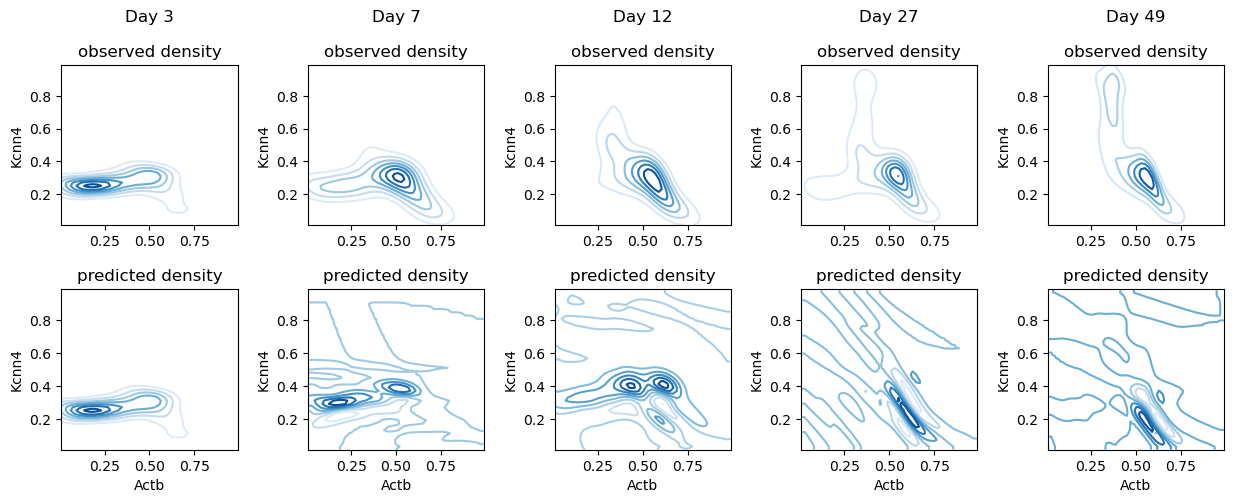

In [42]:
PINN.pl.meshgrid_density_by_time(u_b, u_int_all, train_DS, 'Actb', 'Kcnn4');

# pde neighbor loss

In [5]:
from torch import nn

In [6]:
# CHANG THIS !!!!!
ckpt_path = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/pde_neighborloss/lightning_logs/version_1/checkpoints/epoch=105-total_loss=14.52941990.ckpt"
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")
pde_model = model_class.load_from_checkpoint(ckpt_path)
# load data
# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 5
n_grid = 50

# the DS
from torch.utils.data import DataLoader
train_DS = reader.AllTimepoint_MeshGrid(AnnData=adata, 
                                resampling_indensity=0.3, 
                                resampling_rate=0,
                                n_timepoint = n_timepoint,
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                n_grid=n_grid,  
                                nearby_cellstate=3, 
                                collocation_points=300, 
                                log_transform=False,
                                norm_time = False,
                                n_repeat=2)

batch_size = 50
train_DL = DataLoader(train_DS, batch_size=batch_size, num_workers=10, shuffle=False)

# adata
t7_ad = train_DS.adata.copy()
init_u_b = train_DS.u_b
cellstate = torch.from_numpy(train_DS.cellstate).float().requires_grad_()


  0%|          | 0/4 [00:00<?, ?it/s]

ValueError: cannot reshape array of size 5 into shape (50,50)

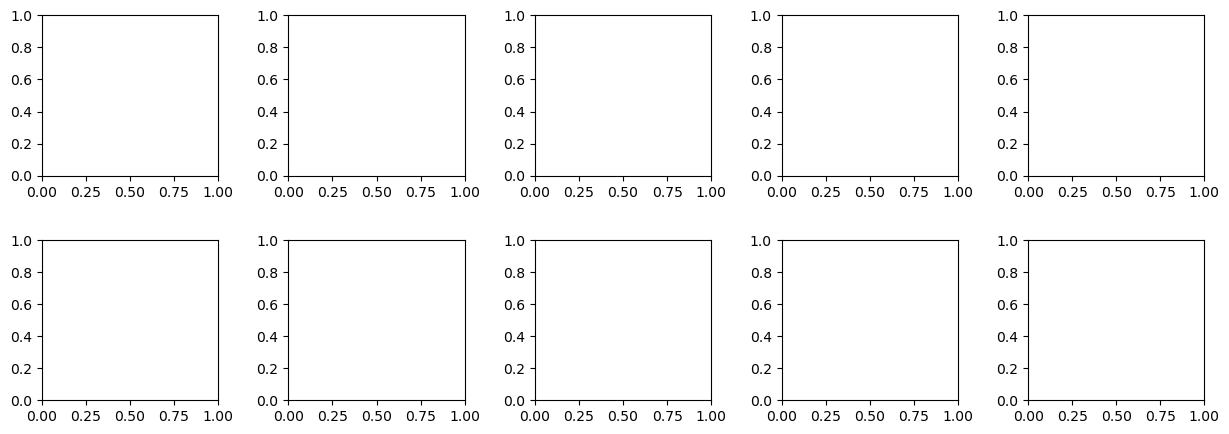

In [50]:

# prediction
t_b = train_DS.t_b[:,0]
t_list = t_b / 5
t_list
## predict u with ode integrat


u_int_all = [init_u_b[0]]
chunk_size= 500
# t_list = timepoints / 15
it = 0
for it in tqdm(range(n_timepoint-1)):
    t0 = t_list[it]
    t1 = t_list[it+1]
    u_t_ls = []

    for train_batch in train_DL:

        (s_bund,s_neighbor), t_b, (u_b, u_neighbor) = train_batch
        s0 = cellstate.to(device)

        ut0 = u_b[:,it]
        utp1 = u_b[:,it+1]
        u_neighbor_t0 = u_neighbor[:, it]


        step_size = np.around((t1 - t0)/15, decimals=1).item() 
        step_size = step_size if step_size > 0 else 0.05
        step_size = min(step_size, 0.4)

        init_condition = ( 
                          s_neighbor.requires_grad_().to(device), 
                          u_neighbor_t0.requires_grad_().to(device))
        
        _, u_neighbor_int = odeint(
                    pde_model.ode_func,
                    init_condition,
                    torch.tensor([t0,t1]).float().to(device),
                    atol=1e-8,
                    rtol=1e-8,
                    method='midpoint',
                    options = {'step_size': step_size}
                )

        torch.cuda.empty_cache()
        u_int = nn.functional.relu(u_neighbor_int[-1])
        u_int = u_int[:,1,1]
        u_t_ls.append(u_int.detach().cpu().numpy())
        torch.cuda.empty_cache()

    u_int = np.concatenate(u_t_ls)
    
    u_int_all.append(u_int)
u_int.shape, len(u_int_all)
[u.shape for u in u_int_all]
u_int_all = np.stack(u_int_all)
u_int_all.shape

In [51]:
u_int_all.shape

(5, 2500)

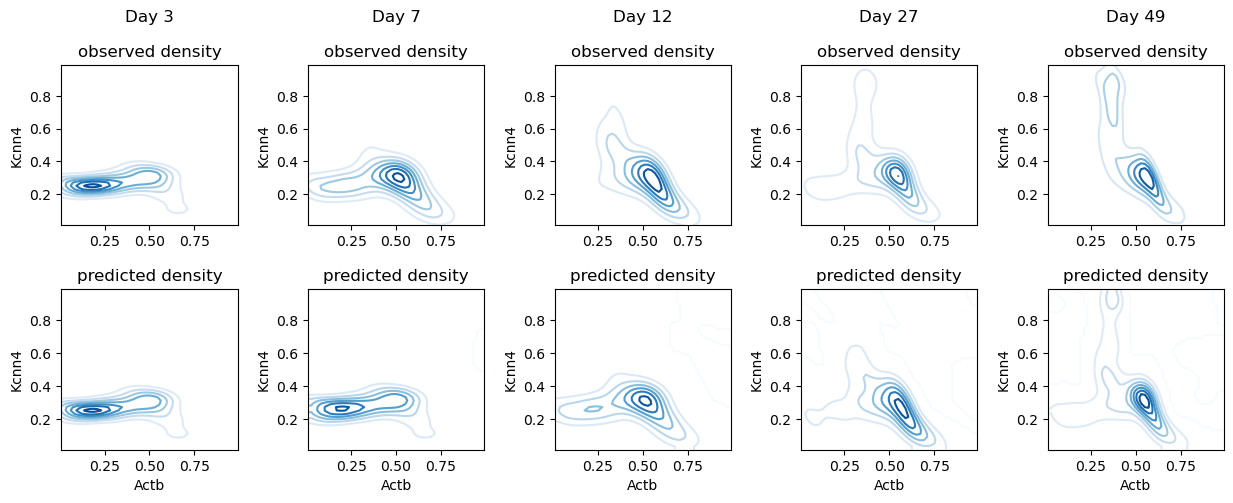

In [52]:
PINN.pl.meshgrid_density_by_time(init_u_b, u_int_all, train_DS, 'Actb', 'Kcnn4');

In [53]:
from scipy import stats

In [54]:
r_ls = []
for i in range(5):
    r_ls.append( stats.pearsonr(init_u_b[i], u_int_all[i])[0] )

Text(0.5, 0, 'timepoints')

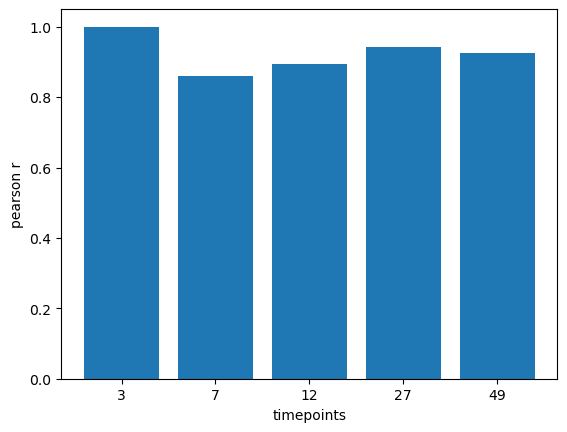

In [58]:
plt.bar(range(5), r_ls)
plt.ylabel("pearson r")
plt.xticks(range(5), train_DS.popD['t'])
plt.xlabel("timepoints")